<a href="https://colab.research.google.com/github/Fedelberg/python_project/blob/main/small_business_owners_in__US.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Analyzing Small Business Owners**

## **Introduction**
This project aims to analyze the characteristics of small business owners using data from the Survey of Consumer Finances (SCF). Understanding the financial and demographic profiles of this group is crucial for tailoring financial products and services, as well as informing policy decisions.

## **Aim of the Project**
The primary goal of this project is to explore the dataset to identify key features and patterns related to small business ownership. Specifically, we will focus on:
- Identifying the proportion of business owners in the dataset.
- Comparing the income distribution, home value vs. household debt, and educational attainment between business owners and non-business owners.
- Creating a subset of the data focusing on small business owners (those with incomes not exceeding $500,000).
- Analyzing the age distribution and feature variance within the small business owner subset.
- Applying K-Means clustering to segment small business owners based on their financial characteristics and interpreting the resulting clusters.

In [ ]:
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import pickle
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.utils.validation import check_is_fitted
from scipy.stats.mstats import trimmed_var
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving SCFP2019.xlsx to SCFP2019.xlsx


In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
SCFP2019 = "SCFP2019.xlsx"
SCFP_Ref_2 = "SCFP_Ref_2.xlsx"

# Read the Excel file into a pandas DataFrame
df = pd.read_excel(SCFP2019)
df2 = pd.read_excel(SCFP_Ref_2)

# Display the first few rows of the DataFrame

print(df.shape)
print(df.head())

(28885, 351)
   YY1  Y1          WGT  HHSEX  AGE  AGECL  EDUC  EDCL  MARRIED  KIDS  ...  \
0    1  11  6119.779308      2   75      6    12     4        2     0  ...   
1    1  12  4712.374912      2   75      6    12     4        2     0  ...   
2    1  13  5145.224455      2   75      6    12     4        2     0  ...   
3    1  14  5297.663412      2   75      6    12     4        2     0  ...   
4    1  15  4761.812371      2   75      6    12     4        2     0  ...   

   NWCAT  INCCAT  ASSETCAT  NINCCAT  NINC2CAT  NWPCTLECAT  INCPCTLECAT  \
0      5       3         6        3         2          10            6   
1      5       3         6        3         1          10            5   
2      5       3         6        3         1          10            5   
3      5       2         6        2         1          10            4   
4      5       3         6        3         1          10            5   

   NINCPCTLECAT  INCQRTCAT  NINCQRTCAT  
0             6          3      

The first thing I notice here is that this dataset is HUGE — over 28,000 rows and 351 column. SO MUCH DATA, I won't explore all of the features in this dataset

I'm going to focus on respondents in df who are business owners by analyzing the "HBUS" column." Reference at "df2, SCFP2_Ref" dataset

***I'm focusing on business owners. But what percentage of the respondents in df are business owners?***

In [ ]:
prop_biz_owners = df["HBUS"].mean()
print("proportion of business owners in df:", prop_biz_owners)

proportion of business owners in df: 0.2740176562229531


Analysis of the dataset revealed that approximately 27.4% of the total respondents identified as business owners. This indicates a significant portion of the survey population is engaged in business ownership

***Is the distribution of income different for business owners and non-business owners?***

In [ ]:
inccat_dict = {
    1: "0-20",
    2: "21-39.9",
    3: "40-59.9",
    4: "60-79.9",
    5: "80-89.9",
    6: "90-100",
}
df_inccat = (
    df["INCCAT"]
    .replace(inccat_dict)
    .groupby(df["HBUS"])
    .value_counts(normalize=True)
    .rename("frequency")
    .to_frame()
    .reset_index()
)

df_inccat

,HBUS,INCCAT,frequency
0,0,0-20,0.210348
1,0,21-39.9,0.198140
2,0,40-59.9,0.189080
3,0,60-79.9,0.186600
4,0,90-100,0.117167
5,0,80-89.9,0.098665
6,1,90-100,0.629438
7,1,60-79.9,0.119015
8,1,80-89.9,0.097410
9,1,40-59.9,0.071510


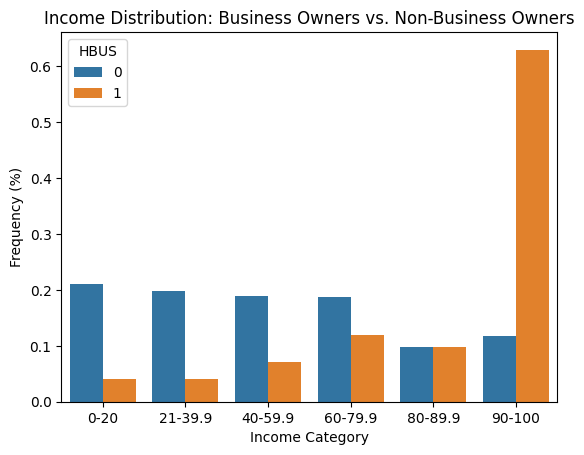

In [ ]:
fig, ax = plt.subplots()

# Create bar chart of `df_inccat`
sns.barplot(
    x="INCCAT",
    y="frequency",
    hue="HBUS",
    data=df_inccat,
    order=inccat_dict.values()
)

plt.xlabel("Income Category")
plt.ylabel("Frequency (%)")
plt.title("Income Distribution: Business Owners vs. Non-Business Owners");

Comparing the income distribution between business owners and non-business owners showed a notable difference. Business owners exhibited a much higher concentration in the higher income categories, particularly in the 90-100% income bracket, compared to non-business owners. This suggests that business ownership is associated with higher income levels in this dataset.

***In the previous project, I looked at the relationship between home value and household debt in the context of the the credit fearful, but what about business owners? Are there notable differences between business owners and non-business owners?***

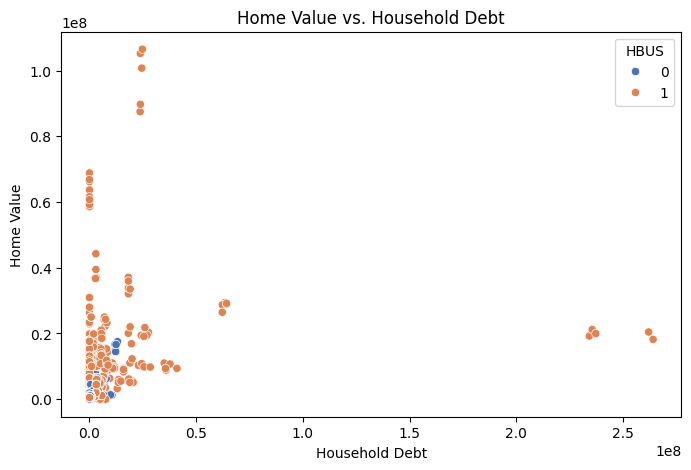

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

# Plot "HOUSES" vs "DEBT" with hue as business ownership
sns.scatterplot(
    x = "DEBT",
    y = "HOUSES",
    hue= "HBUS",
    data=df,
    palette = "deep"
)
plt.xlabel("Household Debt")
plt.ylabel("Home Value")
plt.title("Home Value vs. Household Debt");

A scatter plot visualizing the relationship between home value ('HOUSES') and household debt ('DEBT') for both groups indicated a wide range of values for both variables. While both business and non-business owners showed varied financial situations, business owners generally appeared to have higher values for both home value and household debt. This could suggest that business owners tend to have more substantial assets and potentially utilize debt for investments or other purposes

***Lets create a DataFrame df_educ that shows the normalized frequency for education categories for both the  Business Owners vs. Non-Business Owners in the dataset***

In [ ]:
df_educ = (
    df["EDUC"]
    .groupby(df["HBUS"])
    .value_counts(normalize=True)
    .rename("frequency")
    .to_frame()
    .reset_index()
)

print("df_educ type:", type(df_educ))
print("df_educ shape:", df_educ.shape)
df_educ.head()

df_educ type: <class 'pandas.core.frame.DataFrame'>
df_educ shape: (29, 3)


,HBUS,EDUC,frequency
0,0,8,0.236814
1,0,12,0.214211
2,0,9,0.163138
3,0,13,0.109967
4,0,10,0.061660


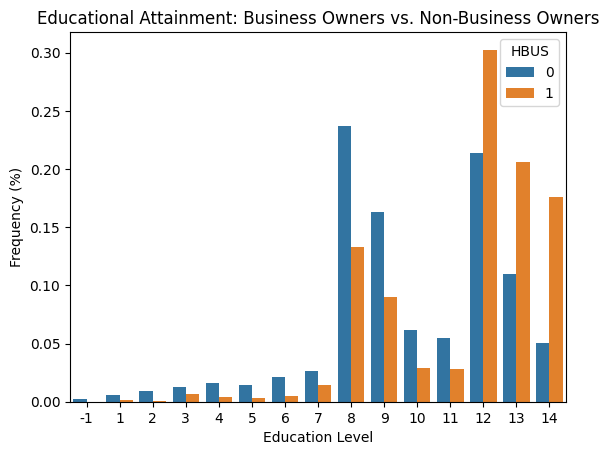

In [ ]:
# Create bar chart of `df_educ`
sns.barplot(
    x="EDUC",
    y="frequency",
    hue="HBUS",
    data=df_educ
)
plt.xlabel("Education Level")
plt.ylabel("Frequency (%)")
plt.title("Educational Attainment: Business Owners vs. Non-Business Owners");

The analysis of educational attainment through a bar chart demonstrated differences between business owners and non-business owners. Business owners showed a higher frequency in certain higher education levels compared to non-business owners, suggesting a potential correlation between higher education and business ownership in this sample

 ***For the model building part, let's look at the respondents who are business owners (HBUS) and  and whose income does not exceed \$500,000.***

In [ ]:
# Filter for business owners with income in categories 1 through 5
mask = (df["HBUS"] == 1) & (df["INCCAT"].isin([1, 2, 3, 4, 5]))
df_small_biz = df[mask]
print("df_small_biz shape:", df_small_biz.shape)
df_small_biz.head()

df_small_biz shape: (2933, 351)


,YY1,Y1,WGT,HHSEX,AGE,AGECL,EDUC,EDCL,MARRIED,KIDS,...,NWCAT,INCCAT,ASSETCAT,NINCCAT,NINC2CAT,NWPCTLECAT,INCPCTLECAT,NINCPCTLECAT,INCQRTCAT,NINCQRTCAT
80,17,171,7802.265717,1,62,4,12,4,1,0,...,3,5,5,5,2,7,9,9,4,4
81,17,172,8247.536301,1,62,4,12,4,1,0,...,3,5,5,5,2,7,9,9,4,4
82,17,173,8169.562719,1,62,4,12,4,1,0,...,3,5,5,5,2,7,9,9,4,4
83,17,174,8087.704517,1,62,4,12,4,1,0,...,3,5,5,5,2,7,9,9,4,4
84,17,175,8276.510048,1,62,4,12,4,1,0,...,3,5,5,5,2,7,9,9,4,4


To focus the subsequent analysis on a more specific group, a subset of the data was created. This subset includes only business owners whose income falls within the first five income categories (INCCAT 1-5), representing those with incomes not exceeding $500,000. This filtered subset comprises 2933 respondents, allowing for a more targeted examination of small business owners.

***I uncovered that credit-fearful respondents were relatively young. Is the same true for small business owners?***

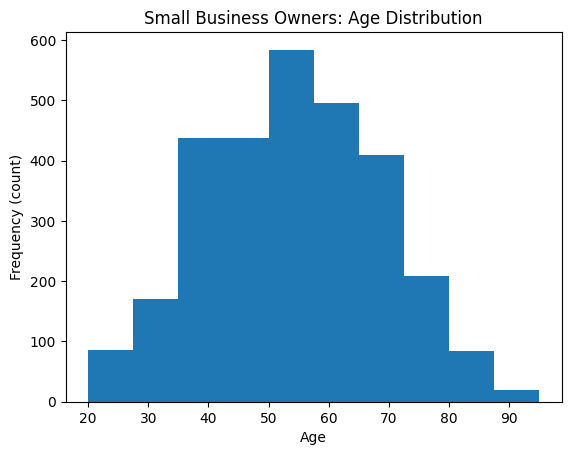

In [ ]:
# Plot histogram of "AGE"
fig, ax = plt.subplots()
df_small_biz["AGE"].plot(kind="hist", bins=10)
plt.xlabel("Age")
plt.ylabel("Frequency (count)")
plt.title("Small Business Owners: Age Distribution");

A histogram of the age of individuals in the small business owner subset revealed a distribution with a peak in the 50-60 age range. This finding contrasts with the previously analyzed "credit fearful" group, who were found to be relatively younger. This suggests that small business owners within this income bracket tend to be more mature

***Let's take a look at the variance in the dataset.***

In [ ]:
# Calculate variance, get 10 largest features
top_ten_var = df_small_biz.var().sort_values().tail(10)
top_ten_var

,0
EQUITY,1.253302e+13
FIN,2.599420e+13
ACTBUS,3.981281e+13
KGBUS,4.111493e+13
BUS,4.179068e+13
KGTOTAL,5.141616e+13
NHNFIN,5.769046e+13
NFIN,8.301937e+13
NETWORTH,1.485596e+14
ASSET,1.618886e+14


***lets remove some outliers to avoid problems in our calculations, so let's trim them out.***

In [ ]:
# Calculate trimmed variance
top_ten_trim_var = (df_small_biz.apply(trimmed_var, limits=(0.1, 0.1)).sort_values().tail(10))

top_ten_trim_var

,0
KGBUS,2.918489e+10
HOUSES,3.641087e+10
FIN,5.490571e+10
KGTOTAL,9.004190e+10
ACTBUS,1.131159e+11
BUS,1.236638e+11
NHNFIN,2.384658e+11
NFIN,4.422106e+11
NETWORTH,7.466420e+11
ASSET,8.025647e+11


***Let's do a quick visualization of those values.***

In [ ]:
# Create horizontal bar chart of `top_ten_trim_var`
fig = px.bar(
    x= top_ten_trim_var,
    y= top_ten_trim_var.index,
    title= "Small Business Owners: High Variance Features"
)
fig.update_layout(xaxis_title="Trimmed Variance [$]", yaxis_title="Feature")
fig.show()

***Based on this graph, which five features have the highest variance?***

In [ ]:
high_var_cols = top_ten_trim_var.tail(5).index.to_list()
high_var_cols

['BUS', 'NHNFIN', 'NFIN', 'NETWORTH', 'ASSET']

 An analysis of the trimmed variance of features within the small business owner subset was conducted to identify variables with the highest variability, as these are often more informative for clustering. The features with the top ten highest trimmed variances were identified, and specifically, the top five features with the highest variability were 'BUS' (Business equity), 'NHNFIN' (Non-home nonfinancial assets), 'NFIN' (Nonfinancial assets), 'NETWORTH' (Net worth), and 'ASSET' (Total assets). These features were selected as the basis for the clustering analysis.

## **Split**

In [ ]:
X = df_small_biz[high_var_cols]
print("X shape:", X.shape)
X.head()

X shape: (2933, 5)


,BUS,NHNFIN,NFIN,NETWORTH,ASSET
80,0.0,224000.0,724000.0,237600.0,810600.0
81,0.0,223000.0,723000.0,236600.0,809600.0
82,0.0,224000.0,724000.0,237600.0,810600.0
83,0.0,222000.0,722000.0,234600.0,808600.0
84,0.0,223000.0,723000.0,237600.0,809600.0


# **Build Model**


## **Iterate**

In [ ]:
n_clusters = range(2, 13)
inertia_errors = []
silhouette_scores = []

# Add `for` loop to train model and calculate inertia, silhouette score.
for k in n_clusters:
    #build model
    model = make_pipeline(StandardScaler(), KMeans(n_clusters=k, random_state=42))
    #train model
    model.fit(X)
    #calculate inertia
    inertia_errors.append(model.named_steps["kmeans"].inertia_)
    #calculate ss
    silhouette_scores.append(silhouette_score(X, model.named_steps["kmeans"].labels_)
    )


print("Inertia:", inertia_errors[:11])
print()
print("Silhouette Scores:", silhouette_scores[:3])

Inertia: [2543.269025625652, 2081.146858797818, 1138.536805416705, 904.347863331241, 786.3945573161894, 377.75143373484406, 357.63215856615864, 239.67885255110158, 221.78649804520123, 192.4691005974072, 179.34440273466188]

Silhouette Scores: [np.float64(0.9763591803663393), np.float64(0.9726791599735125), np.float64(0.9383013985199563)]


In [ ]:
# Create line plot of `inertia_errors` vs `n_clusters`
fig = px.line(
    x= n_clusters, y= inertia_errors, title= "K-Means Model: Inertia vs Number of Clusters"
)
fig.update_layout(xaxis_title= "Number of Clusters (k)", yaxis_title= "Inertia")

fig.show()

The trick with choosing the right number of clusters is to look for the "bend in the elbow" for this plot. I want to pick the point where the drop in inertia becomes less dramatic and the line begins to flatten out. In this case, it looks like the sweet spot is 3 or 4.

***Let's see what the silhouette score looks like.***

In [ ]:
# Create a line plot of `silhouette_scores` vs `n_clusters`
fig = px.line(
    x= n_clusters,
    y= silhouette_scores,
    title= "K-Means Model: Silhouette Score vs Number of Clusters"
)
fig.update_layout(xaxis_title= "Number of Clusters (k)", yaxis_title= "Silhouette Score")
fig.show()

In contrast to our inertia plot, bigger is better. So we're not looking for a "bend in the elbow" but rather a number of clusters for which the silhouette score still remains high. I can see that silhouette score drops drastically beyond 3 clusters. Given this and what we saw in the inertia plot, it looks like the optimal number of clusters is 3.

***Now that i've  number of clusters to be  3, it's time to build the final model.***

In [ ]:
final_model = make_pipeline(
    StandardScaler(),
    KMeans(n_clusters=3, random_state=42)
)

# Fit model to data
final_model.fit(X)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('kmeans', KMeans(n_clusters=3, random_state=42))])

# **Communicate**

In [ ]:
labels = final_model.named_steps["kmeans"].labels_
xgb = X.groupby(labels).mean()
xgb

,BUS,NHNFIN,NFIN,NETWORTH,ASSET
0,6.703538e+05,8.992055e+05,1.319826e+06,1.687392e+06,1.871307e+06
1,5.214271e+07,6.873669e+07,7.771398e+07,1.250334e+08,1.267218e+08
2,9.314757e+07,1.010385e+08,1.301742e+08,1.291482e+08,1.427424e+08


In [ ]:
# Create side-by-side bar chart of `xgb`

fig = px.bar(
    xgb,
    barmode="group",
    title="Small Business Owner Finances by Cluster"
)
fig.update_layout(xaxis_title="Cluster", yaxis_title="Value [$]")
fig.show()

In [ ]:
# Instantiate transformer
pca =  PCA(n_components=2, random_state=42)

# Transform `X`
X_t = pca.fit_transform(X)

# Put `X_t` into DataFrame
X_pca =  pd.DataFrame(X_t, columns=["PC1","PC2"])

print("X_pca shape:", X_pca.shape)
X_pca.head()

X_pca shape: (2933, 2)


,PC1,PC2
0,-3.917230e+06,167696.314686
1,-3.919107e+06,167642.309850
2,-3.917230e+06,167696.314686
3,-3.921538e+06,168036.046131
4,-3.918555e+06,167194.568733


In [ ]:
# Create scatter plot of `PC2` vs `PC1`
fig = px.scatter(
    data_frame=X_pca,
    x="PC1",
    y="PC2",
    color=labels.astype(str),
    title="PCA Representation of Clusters"
)
fig.update_layout(xaxis_title="PC1", yaxis_title="PC2")
fig.show()

Now, let's look at each cluster individually:

**Cluster 0:**

*   Looking at the bar chart, Cluster 0 has significantly lower mean values across all five features ('BUS', 'NHNFIN', 'NFIN', 'NETWORTH', and 'ASSET') compared to the other two clusters.
*   The average 'NETWORTH' and 'ASSET' for this cluster are the lowest, indicating that individuals in this cluster have the least overall wealth and total assets among the small business owners analyzed.
*   Their average 'BUS' (Business equity) is also the lowest, suggesting smaller business holdings or less equity in their businesses.
*   Similarly, their average 'NHNFIN' (Non-home nonfinancial assets) and 'NFIN' (Nonfinancial assets) are the lowest, indicating fewer assets outside of real estate and financial investments.

**In summary:** Cluster 0 appears to represent small business owners with relatively lower levels of wealth and assets across the board.

**Cluster 1:**

*   Cluster 1 shows substantially higher mean values for all features compared to Cluster 0.
*   Specifically, 'BUS' (Business equity) has a very high mean value in this cluster, indicating a significant amount of wealth tied up in their businesses.
*   'NHNFIN' (Non-home nonfinancial assets) and 'NFIN' (Nonfinancial assets) are also considerably higher than in Cluster 0, suggesting more substantial non-financial assets.
*   'NETWORTH' and 'ASSET' are also significantly higher than in Cluster 0, reflecting a much greater overall wealth and total asset base.

**In summary:** Cluster 1 seems to represent small business owners with high levels of wealth, particularly driven by substantial business equity.

**Cluster 2:**

*   Cluster 2 also exhibits high mean values for all features, comparable to or even exceeding Cluster 1 in some cases.
*   Interestingly, Cluster 2 has the highest mean values for 'NHNFIN' (Non-home nonfinancial assets) and 'NFIN' (Nonfinancial assets). This suggests that individuals in this cluster have a larger proportion of their wealth in non-financial assets outside of their homes.
*   Their mean 'BUS' (Business equity) is also very high, similar to Cluster 1.
*   'NETWORTH' and 'ASSET' are also very high, indicating significant overall wealth and total assets.

**In summary:** Cluster 2 appears to represent small business owners with high levels of wealth, with a slightly greater emphasis on non-home nonfinancial assets compared to Cluster 1.

**Overall Comparison:**

The clustering effectively segments small business owners into groups with distinct financial profiles. Cluster 0 represents a group with lower wealth and assets, while Clusters 1 and 2 represent wealthier groups with different compositions of their assets, particularly in terms of business equity versus other non-financial assets. This kind of segmentation can be very useful for understanding the diverse financial landscapes of small business owners.